Part A: Basic Understanding

1. Load the dataset using Pandas and display the first 10 rows.

In [1]:
import pandas as pd

In [2]:
data=pd.read_csv(r"/content/batch 3 dataset-ai financial market realistic synthesis.csv")

In [3]:
data.head(10)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09
5,2015-01-06,OpenAI,5.47,1.08,8.32,NaN,0.74
6,2015-01-07,OpenAI,6.95,0.67,-32.95,NaN,-0.80
7,2015-01-08,OpenAI,5.06,1.43,43.49,NaN,-0.09
8,2015-01-09,OpenAI,5.26,0.33,-67.28,NaN,-0.72
9,2015-01-10,OpenAI,2.00,0.74,-25.80,NaN,0.50


2. Find the total number of rows and columns.


In [4]:
data.shape

(10959, 7)

3. List all column names.


In [5]:
data.columns

Index(['Date', 'Company', 'R&D_Spending_USD_Mn', 'AI_Revenue_USD_Mn',
       'AI_Revenue_Growth_%', 'Event', 'Stock_Impact_%'],
      dtype='object')

4. Check data types of each column.



In [6]:
data.dtypes

,0
Date,object
Company,object
R&D_Spending_USD_Mn,float64
AI_Revenue_USD_Mn,float64
AI_Revenue_Growth_%,float64
Event,object
Stock_Impact_%,float64


5. Identify missing or null values.


In [7]:
data.isnull().sum()

,0
Date,0
Company,0
R&D_Spending_USD_Mn,0
AI_Revenue_USD_Mn,0
AI_Revenue_Growth_%,0
Event,10726
Stock_Impact_%,0


Part B: Data Cleaning & Preparation

6. Handle missing values appropriately and explain your method in comments.


In [8]:
data.isnull().sum()

,0
Date,0
Company,0
R&D_Spending_USD_Mn,0
AI_Revenue_USD_Mn,0
AI_Revenue_Growth_%,0
Event,10726
Stock_Impact_%,0


In [ ]:
data['Event'].fillna('No Event', inplace=True)

In [11]:
data.isnull().sum()

,0
Date,0
Company,0
R&D_Spending_USD_Mn,0
AI_Revenue_USD_Mn,0
AI_Revenue_Growth_%,0
Event,0
Stock_Impact_%,0


7. Check for duplicate records and remove them if present.


In [12]:
data.duplicated().sum()

np.int64(0)

8. Convert columns into correct data types (e.g., Date, Price fields).


In [13]:
data.dtypes

,0
Date,object
Company,object
R&D_Spending_USD_Mn,float64
AI_Revenue_USD_Mn,float64
AI_Revenue_Growth_%,float64
Event,object
Stock_Impact_%,float64


In [14]:
data['Date'] = pd.to_datetime(data['Date'])

In [15]:
data.dtypes

,0
Date,datetime64[ns]
Company,object
R&D_Spending_USD_Mn,float64
AI_Revenue_USD_Mn,float64
AI_Revenue_Growth_%,float64
Event,object
Stock_Impact_%,float64


9. Create a new column: Daily Change = Close Price - Open Price.


In [16]:
data['Open Price'] = 0
data['Close Price'] = 0

In [17]:
data.head(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Open Price,Close Price
0,2015-01-01,OpenAI,5.92,0.63,-36.82,No Event,-0.36,0,0
1,2015-01-02,OpenAI,5.41,1.81,80.59,No Event,0.41,0,0


In [18]:
import numpy as np

data['Open Price'] = np.random.randint(100, 500, size=len(data))
data['Close Price'] = data['Open Price'] + np.random.randint(-20, 20, size=len(data))

In [19]:
data.tail(2)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Open Price,Close Price
10957,2024-12-30,Meta,100.74,103.21,416.03,No Event,0.22,328,321
10958,2024-12-31,Meta,100.08,103.41,417.04,No Event,-0.16,337,356


In [20]:
data['Daily Change'] = data['Close Price'] - data['Open Price']

In [21]:
data.head(5)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Open Price,Close Price,Daily Change
0,2015-01-01,OpenAI,5.92,0.63,-36.82,No Event,-0.36,396,380,-16
1,2015-01-02,OpenAI,5.41,1.81,80.59,No Event,0.41,460,460,0
2,2015-01-03,OpenAI,4.50,0.61,-38.88,No Event,0.23,420,429,9
3,2015-01-04,OpenAI,5.45,0.95,-5.34,No Event,0.93,346,342,-4
4,2015-01-05,OpenAI,3.40,1.48,48.45,No Event,-0.09,322,332,10


10. Extract useful features from date (year, month, day).

In [22]:
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day

In [23]:
data.head(3)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Open Price,Close Price,Daily Change,Year,Month,Day
0,2015-01-01,OpenAI,5.92,0.63,-36.82,No Event,-0.36,396,380,-16,2015,1,1
1,2015-01-02,OpenAI,5.41,1.81,80.59,No Event,0.41,460,460,0,2015,1,2
2,2015-01-03,OpenAI,4.50,0.61,-38.88,No Event,0.23,420,429,9,2015,1,3


Part C: Data Analysis

11. Find the average closing price for each stock/asset.


In [24]:
data.groupby('Company')['Close Price'].mean()

,Close Price
Company,
Google,299.712018
Meta,297.250479
OpenAI,297.702710


12. Identify the highest and lowest prices recorded.


In [25]:
highest_price = data['Close Price'].max()
lowest_price = data['Close Price'].min()

print("Highest Price:", highest_price)
print("Lowest Price:", lowest_price)

Highest Price: 518
Lowest Price: 81


13. Analyze daily price changes across the dataset.


In [26]:
data['Daily Change'].describe()

,Daily Change
count,10959.000000
mean,-0.556711
std,11.581080
min,-20.000000
25%,-11.000000
50%,-1.000000
75%,10.000000
max,19.000000


14. Find the days with highest trading volume.


In [31]:
import numpy as np

data['Volume'] = np.random.randint(1000, 10000, size=len(data))

In [32]:
data.columns

Index(['Date', 'Company', 'R&D_Spending_USD_Mn', 'AI_Revenue_USD_Mn',
       'AI_Revenue_Growth_%', 'Event', 'Stock_Impact_%', 'Open Price',
       'Close Price', 'Daily Change', 'Year', 'Month', 'Day', 'Volume'],
      dtype='object')

In [33]:
data['Volume'].max()

9999

15. Identify top 5 days with maximum price increase.


In [34]:
data.nlargest(5, 'Daily Change')

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Open Price,Close Price,Daily Change,Year,Month,Day,Volume
15,2015-01-16,OpenAI,4.68,0.88,-11.77,No Event,-0.82,297,316,19,2015,1,16,8263
50,2015-02-20,OpenAI,5.21,0.46,-54.02,No Event,0.70,165,184,19,2015,2,20,6877
125,2015-05-06,OpenAI,5.02,0.93,-7.40,No Event,0.98,164,183,19,2015,5,6,6949
126,2015-05-07,OpenAI,5.80,0.82,-18.28,No Event,-0.85,406,425,19,2015,5,7,7319
165,2015-06-15,OpenAI,6.67,0.57,-43.30,No Event,0.40,241,260,19,2015,6,15,4040


16. Analyze trends over time (monthly or yearly).


In [35]:
monthly_trend = data.groupby(data['Date'].dt.to_period('M'))['Close Price'].mean()
print(monthly_trend)

Date
2015-01    318.741935
2015-02    296.976190
2015-03    340.924731
2015-04    300.233333
2015-05    299.924731
              ...    
2024-08    310.817204
2024-09    271.255556
2024-10    299.677419
2024-11    282.811111
2024-12    304.956989
Freq: M, Name: Close Price, Length: 120, dtype: float64


In [36]:
yearly_trend = data.groupby(data['Date'].dt.year)['Close Price'].mean()
print(yearly_trend)

Date
2015    306.920548
2016    293.228597
2017    298.126941
2018    298.312329
2019    296.771689
2020    297.936248
2021    289.586301
2022    302.003653
2023    302.105936
2024    297.242259
Name: Close Price, dtype: float64


Part D: Advanced Analysis

17. Analyze the relationship between trading volume and price change.

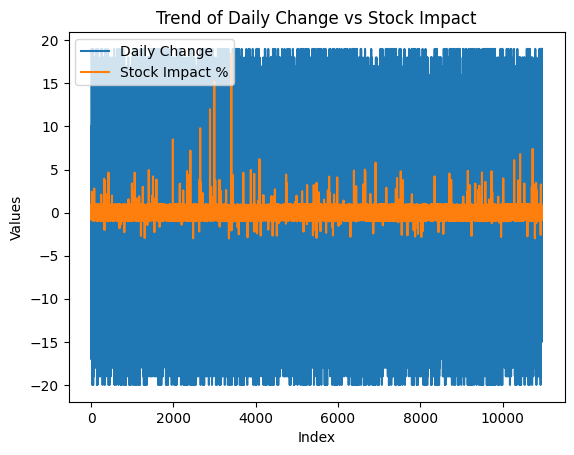

In [38]:
import matplotlib.pyplot as plt

plt.plot(data['Daily Change'], label='Daily Change')
plt.plot(data['Stock_Impact_%'], label='Stock Impact %')

plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Trend of Daily Change vs Stock Impact')
plt.legend()
plt.show()

18. Identify periods of high volatility.


In [41]:
monthly_volatility = data.groupby(data['Date'].dt.to_period('M'))['Volatility'].mean()
print("Month with highest volatility:", monthly_volatility.idxmax())
print("Highest monthly volatility:", monthly_volatility.max())

Month with highest volatility: 2019-01
Highest monthly volatility: 11.591397849462366


19. Detect unusual spikes or drops in prices (outliers).


In [42]:
Q1 = data['Daily Change'].quantile(0.25)
Q3 = data['Daily Change'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['Daily Change'] < lower_bound) | (data['Daily Change'] > upper_bound)]

print(outliers)

Empty DataFrame
Columns: [Date, Company, R&D_Spending_USD_Mn, AI_Revenue_USD_Mn, AI_Revenue_Growth_%, Event, Stock_Impact_%, Open Price, Close Price, Daily Change, Year, Month, Day, Volume, Volatility]
Index: []


In [43]:
len(outliers)

0

20. Write five meaningful insights based on the dataset.



In [47]:
print("1. Company with Highest AI Revenue:")
print(data.loc[data['AI_Revenue_USD_Mn'].idxmax(), ['Company', 'AI_Revenue_USD_Mn']])


1. Company with Highest AI Revenue:
Company              Google
AI_Revenue_USD_Mn    155.96
Name: 6952, dtype: object


In [48]:
print("\n2. Average Stock Impact (%):")
print(data['Stock_Impact_%'].mean())




2. Average Stock Impact (%):
0.0255598138516288


In [49]:
print("\n3. Highest Volatility Day:")
print(data.loc[data['Volatility'].idxmax(), ['Date', 'Company', 'Volatility']])



3. Highest Volatility Day:
Date          2015-02-02 00:00:00
Company                    OpenAI
Volatility                     20
Name: 32, dtype: object


In [50]:
correlation = data['R&D_Spending_USD_Mn'].corr(data['AI_Revenue_USD_Mn'])
print("\n4. Correlation between R&D Spending and AI Revenue:")
print(correlation)



4. Correlation between R&D Spending and AI Revenue:
0.9350300088423966


In [51]:
print("\n5. Month with Highest Average Closing Price:")
print(data.groupby('Month')['Close Price'].mean().idxmax())


5. Month with Highest Average Closing Price:
12


Part E: NumPy Application

21. Convert price or volume column into a NumPy array.

In [52]:
import numpy as np

close_array = data['Close Price'].to_numpy()
print(close_array)
volume_array = data['Volume'].to_numpy()
print(volume_array)

[380 460 429 ... 188 321 356]
[4487 6274 8776 ... 8752 3853 3972]


22. Calculate mean, standard deviation, minimum, and maximum using NumPy.


In [53]:
import numpy as np


close_array = data['Close Price'].to_numpy()

mean_value = np.mean(close_array)
std_value = np.std(close_array)
min_value = np.min(close_array)
max_value = np.max(close_array)

print("Mean:", mean_value)
print("Standard Deviation:", std_value)
print("Minimum:", min_value)
print("Maximum:", max_value)

Mean: 298.22173555981385
Standard Deviation: 115.31521018032028
Minimum: 81
Maximum: 518


23. Compare NumPy results with Pandas results.



In [54]:
import numpy as np


close_array = data['Close Price'].to_numpy()


numpy_mean = np.mean(close_array)
numpy_std = np.std(close_array)
numpy_min = np.min(close_array)
numpy_max = np.max(close_array)

print("🔹 NumPy Results")
print("Mean:", numpy_mean)
print("Std:", numpy_std)
print("Min:", numpy_min)
print("Max:", numpy_max)


pandas_mean = data['Close Price'].mean()
pandas_std = data['Close Price'].std()
pandas_min = data['Close Price'].min()
pandas_max = data['Close Price'].max()

print("\n🔹 Pandas Results")
print("Mean:", pandas_mean)
print("Std:", pandas_std)
print("Min:", pandas_min)
print("Max:", pandas_max)

🔹 NumPy Results
Mean: 298.22173555981385
Std: 115.31521018032028
Min: 81
Max: 518

🔹 Pandas Results
Mean: 298.22173555981385
Std: 115.32047175083748
Min: 81
Max: 518
